In [361]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#### Dataset from kaggle = https://www.kaggle.com/datasets/ghazouanihaythem/loan-eligibility-dataset/data

In [362]:
df = pd.read_csv('D:\Tech Axis Exam\Tech_Axis_Exam\loan_Data.csv')

In [363]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [364]:
def Loan_Amount(x):
    return (x['LoanAmount'] * x['Loan_Amount_Term'] * 15 )/ 100



In [365]:
df.shape

(614, 13)

In [366]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 83.4 KB


In [367]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


### Q2


In [368]:
df['Gender'].value_counts()

Gender
Male      489
Female    112
Name: count, dtype: int64

In [369]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [370]:
df['Credit_History'].value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

In [371]:
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [372]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])

In [373]:
df['Gender'].value_counts()

Gender
Male      502
Female    112
Name: count, dtype: int64

In [374]:
df['Dependents'].value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

In [375]:
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])  

In [376]:
df.drop('Loan_ID', axis=1, inplace=True)

In [377]:
df

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [378]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    str    
 1   Married            614 non-null    str    
 2   Dependents         614 non-null    str    
 3   Education          614 non-null    str    
 4   Self_Employed      614 non-null    str    
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 73.7 KB


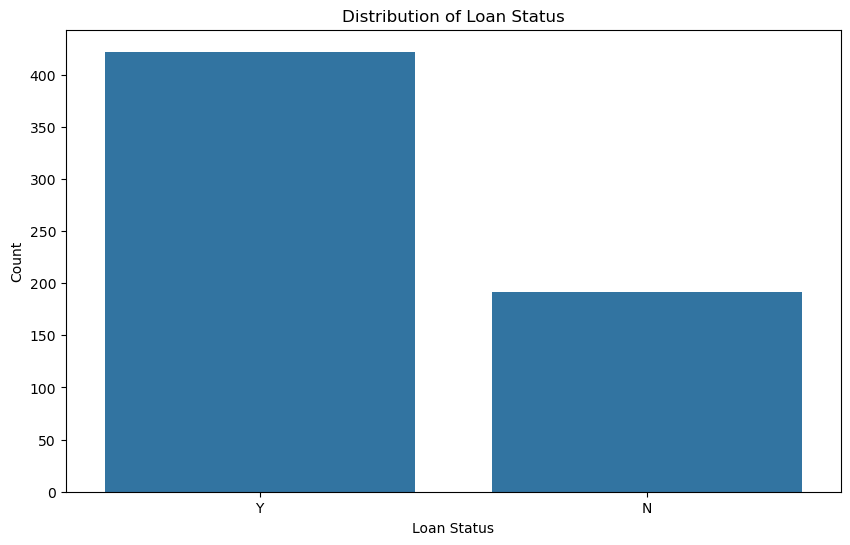

In [379]:
plt.figure(figsize=(10,6))
sns.countplot(x='Loan_Status', data=df)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status')   
plt.ylabel('Count')
plt.show()

## Here in these datasets, we can see that there is high number of loan approved and less number of loan be not accepted. Which means that there is high probability of being loan approved


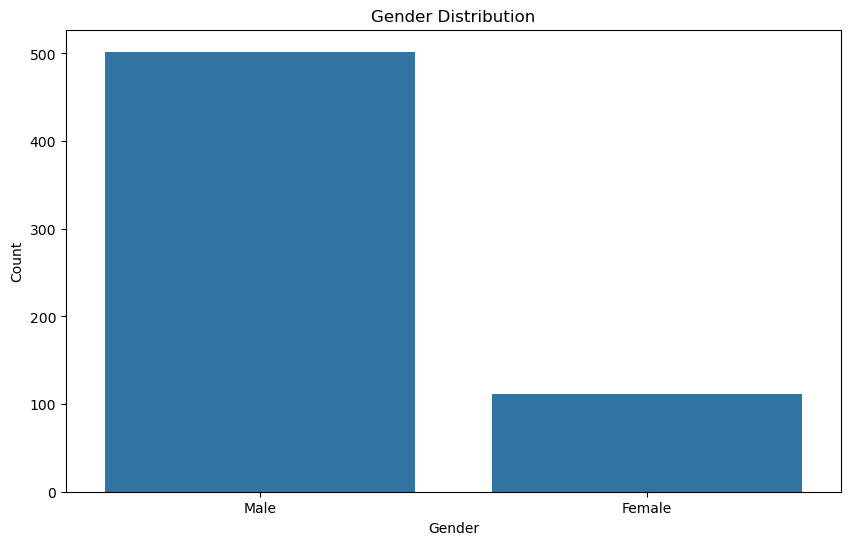

In [380]:
plt.figure(figsize=(10,6))
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.xlabel('Gender')   
plt.ylabel('Count')
plt.show()

## From these plot, we gain to know that the number of loan taken are mostly by male than female from these datasets.

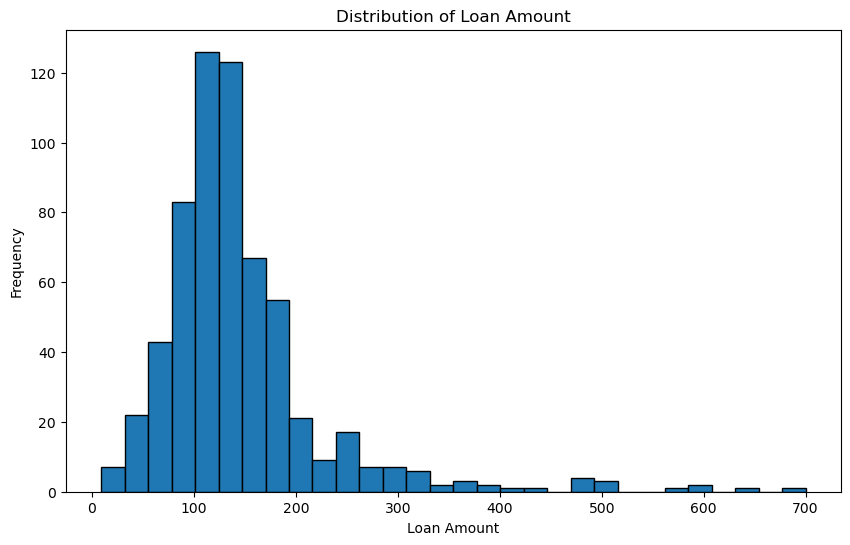

In [381]:
plt.figure(figsize=(10,6))
plt.hist(df['LoanAmount'], bins=30, edgecolor='k')
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')   
plt.ylabel('Frequency')
plt.show()

### From these plot, we get to see that most people takes loan on the range between 50 - 140 (in thousands of dollars).

### Q4

In [382]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    str    
 1   Married            614 non-null    str    
 2   Dependents         614 non-null    str    
 3   Education          614 non-null    str    
 4   Self_Employed      614 non-null    str    
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 73.7 KB


In [383]:
df['Dependents'].unique()

<ArrowStringArray>
['0', '1', '2', '3+']
Length: 4, dtype: str

In [384]:
df['Education'].unique()

<ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

In [385]:
df['Self_Employed'].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

In [386]:
df['Loan_Status'].unique()

<ArrowStringArray>
['Y', 'N']
Length: 2, dtype: str

In [387]:
df['Property_Area'].unique()

<ArrowStringArray>
['Urban', 'Rural', 'Semiurban']
Length: 3, dtype: str

In [388]:
df['Gender'].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [389]:
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

In [390]:
order_gender = ['Male', 'Female']
encoder = OrdinalEncoder(categories=[order_gender], dtype=int)
df['Gender'] = encoder.fit_transform(df[['Gender']])

In [391]:
df['Gender'].unique()

array([0, 1])

In [392]:
df['Married'].unique()

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

## Let's encode all the columns

In [393]:
order_self_employed = ['No', 'Yes']
order_dependents = ['0', '1', '2', '3+']
order_education = ['Not Graduate', 'Graduate']
order_property_area = ['Rural', 'Semiurban', 'Urban']
order_loan_status = ['N', 'Y']
order_married = ['No', 'Yes']
# encoder = OrdinalEncoder(categories=[order_self_employed], dtype=int)
# encoder = OrdinalEncoder(categories=[order_dependents], dtype=int)
# encoder = OrdinalEncoder(categories=[order_education], dtype=int)
# encoder = OrdinalEncoder(categories=[order_property_area], dtype=int)
# encoder = OrdinalEncoder(categories=[order_loan_status], dtype=int)
# encoder = OrdinalEncoder(categories=[order_married], dtype=int)

all_encoder = OrdinalEncoder(categories=[order_self_employed, order_dependents, order_education, order_property_area, order_loan_status, order_married], dtype=int)

df[['Self_Employed', 'Dependents', 'Education', 'Property_Area', 'Loan_Status', 'Married']] = all_encoder.fit_transform(df[['Self_Employed', 'Dependents', 'Education', 'Property_Area', 'Loan_Status', 'Married']])

In [394]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 57.7 KB


### Let's begin question no. 5

In [395]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1
1,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0
2,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1
3,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1
4,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1


In [396]:
# df['Total_Loan_Amount'] = df['Total_loan_amount'].apply(Loan_Amount, axis=1)
df['Total_Loan_Amount'] = df.apply(Loan_Amount, axis=1)

In [397]:
from sklearn.model_selection import train_test_split

In [398]:
df['Total_Loan_Amount']

0       6912.0
1       6912.0
2       3564.0
3       6480.0
4       7614.0
        ...   
609     3834.0
610     1080.0
611    13662.0
612    10098.0
613     7182.0
Name: Total_Loan_Amount, Length: 614, dtype: float64

In [399]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Loan_Amount
0,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1,6912.0
1,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,6912.0
2,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,3564.0
3,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,6480.0
4,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,7614.0


In [400]:
X = df.drop(columns=['Loan_Status', 'Total_Loan_Amount'])
y = df['Total_Loan_Amount']

In [401]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#### We use the test_size = 0.25 cause taking high % to test the data than train size effect in learning process of model in the low datasets. And taking low % to test the data may effect the result or the output and may cause the problem for the real world. 

In [402]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    int64  
 11  Loan_Status        614 non-null    int64  
 12  Total_Loan_Amount  614 non-null    float64
dtypes: float64(5), int64(8)
memory usage: 62.5 KB


### Question no.6

In [403]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Loan_Amount
0,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1,6912.0
1,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,6912.0
2,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,3564.0
3,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,6480.0
4,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,7614.0


In [404]:
from sklearn.linear_model import LinearRegression, LogisticRegression

In [405]:
df.describe()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Loan_Amount
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,0.182410,0.653094,0.744300,0.781759,0.133550,5403.459283,1621.245798,145.752443,342.410423,0.855049,1.037459,0.687296,7516.067101
std,0.386497,0.476373,1.009623,0.413389,0.340446,6109.041673,2926.248369,84.107233,64.428629,0.352339,0.787482,0.463973,4603.637439
min,0.000000,0.000000,0.000000,0.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000,0.000000,0.000000,199.800000
25%,0.000000,0.000000,0.000000,1.000000,0.000000,2877.500000,0.000000,100.250000,360.000000,1.000000,0.000000,0.000000,5130.000000
50%,0.000000,1.000000,0.000000,1.000000,0.000000,3812.500000,1188.500000,128.000000,360.000000,1.000000,1.000000,1.000000,6804.000000
75%,0.000000,1.000000,1.000000,1.000000,0.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000,2.000000,1.000000,8640.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000,2.000000,1.000000,46800.000000


In [406]:
Linear_model = LinearRegression()
Linear_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Linear Regression Trained

In [407]:
y_pred = Linear_model.predict(X_test)

In [408]:
y_pred

array([12297.01732548,  7071.93029804,  8388.71168898,  3808.41076194,
        3934.23786126,  5694.4509123 ,  6449.95200322,  3834.42671964,
        9220.91851007,  6111.6472718 ,  3868.87556995,  8205.10241542,
        7301.53593734,  6829.23972988,  4841.86682188,  4075.61581353,
        3413.24326661,  8182.71972211,  7536.65060124,   632.80078607,
        7030.92243456, 12598.13890463, 10818.10845018, 10769.13129445,
        2107.57137641, 10013.84335296,  7035.06244903,  6997.97917809,
        2997.28335063, -1344.00673224,  3813.43701271,  5261.79786575,
        5753.4853346 ,  6086.93016847, 11983.82103151, 11799.80419776,
        9403.63158951,  6881.51534512,  5194.17810108,  8925.92646761,
        7529.51585198,  7005.95329956,  8364.92892341,  5894.4685122 ,
        4180.6595857 ,  6717.28622371, 10842.9369247 ,  5724.60683934,
        8010.57295233,  5598.30688294, 10500.25024852, 11500.18464212,
        5181.11485365,  5150.0959449 ,  9343.68327202,  6074.8461081 ,
      

### Q6 Completed

In [409]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [410]:
MSE = mean_squared_error(y_test, y_pred)
R2 = r2_score(y_test, y_pred)
MAE = mean_absolute_error(y_test, y_pred)

print(f'Mean Squared Error: {MSE}')
print(f'R-Squared: {R2}')
print(f'Mean Absolute Error: {MAE}')

Mean Squared Error: 1827539.9202899507
R-Squared: 0.8781312421537724
Mean Absolute Error: 329.29308924705924


### Q 7 Completed, model appropriate metrics

### Let's begin Question number 8

In [411]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score, precision_score, recall_score


In [412]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Loan_Amount
0,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1,6912.0
1,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,6912.0
2,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,3564.0
3,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,6480.0
4,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,7614.0


In [413]:
df_before = df.drop(columns=['Total_Loan_Amount'])
df_after = df

In [414]:
tree_model = DecisionTreeClassifier(
    criterion = 'gini',
    splitter = 'best',
    max_depth = 45,
    min_samples_split = 6,
    min_samples_leaf = 4,
    max_features = 7,
    random_state = 42,
    max_leaf_nodes = 5
)

In [415]:
X_train, X_test, y_train, y_test = train_test_split(df_before.drop(['Loan_Status'], axis=1), df_before['Loan_Status'], test_size=0.25, random_state=42)

In [416]:
tree_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,45
,min_samples_split,6
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,7
,random_state,42
,max_leaf_nodes,5
,min_impurity_decrease,0.0
,class_weight,None


In [417]:
y_pred = tree_model.predict(X_test)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1])

In [418]:
# from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)


print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{class_report}')
print(f'F1 Score: {f1}')
print(f'ROC AUC Score: {roc_auc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

Accuracy: 0.7792207792207793
Confusion Matrix:
[[22 32]
 [ 2 98]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.41      0.56        54
           1       0.75      0.98      0.85       100

    accuracy                           0.78       154
   macro avg       0.84      0.69      0.71       154
weighted avg       0.81      0.78      0.75       154

F1 Score: 0.8521739130434782
ROC AUC Score: 0.6937037037037037
Precision: 0.7538461538461538
Recall: 0.98


### Q 9 applied feature scaling

In [419]:
df_after.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Loan_Amount
0,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1,6912.0
1,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,6912.0
2,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,3564.0
3,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,6480.0
4,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,7614.0


In [420]:
X_train, X_test, y_train, y_test = train_test_split(df_after.drop(columns=['Loan_Status']), df_after['Loan_Status'], test_size=0.25, random_state=42)

In [422]:
tree_model2 = DecisionTreeClassifier(
    criterion = 'gini', 
    splitter = 'best',
    max_depth = 45, 
    min_samples_split = 6,
    min_samples_leaf = 4,
    max_features = 7,
    random_state = 42,  
)

tree_model2.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,45
,min_samples_split,6
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,7
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [423]:
tree2_pred = tree_model2.predict(X_test)

In [424]:
accuracy = accuracy_score(y_test, tree2_pred)
conf_matrix = confusion_matrix(y_test, tree2_pred)
class_report = classification_report(y_test, tree2_pred)
f1 = f1_score(y_test, tree2_pred)
roc_auc = roc_auc_score(y_test, tree2_pred)
precision = precision_score(y_test, tree2_pred)
recall = recall_score(y_test, tree2_pred)


print(f'Accuracy: {accuracy}')
print(f'Confusion Matrix:\n{conf_matrix}')
print(f'Classification Report:\n{class_report}')
print(f'F1 Score: {f1}')
print(f'ROC AUC Score: {roc_auc}')
print(f'Precision: {precision}')
print(f'Recall: {recall}')

Accuracy: 0.6753246753246753
Confusion Matrix:
[[31 23]
 [27 73]]
Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.57      0.55        54
           1       0.76      0.73      0.74       100

    accuracy                           0.68       154
   macro avg       0.65      0.65      0.65       154
weighted avg       0.68      0.68      0.68       154

F1 Score: 0.7448979591836735
ROC AUC Score: 0.652037037037037
Precision: 0.7604166666666666
Recall: 0.73


### We can see difference between before scaling and after scaling

### Q10 start


In [426]:
from sklearn.neighbors import KNeighborsClassifier

In [429]:
df_knn = df 
df_knn.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Loan_Amount
0,0,0,0,1,0,5849,0.0,128.0,360.0,1.0,2,1,6912.0
1,0,1,1,1,0,4583,1508.0,128.0,360.0,1.0,0,0,6912.0
2,0,1,0,1,1,3000,0.0,66.0,360.0,1.0,2,1,3564.0
3,0,1,0,0,0,2583,2358.0,120.0,360.0,1.0,2,1,6480.0
4,0,0,0,1,0,6000,0.0,141.0,360.0,1.0,2,1,7614.0


In [430]:
x = df_knn.drop(columns=['Loan_Status'])
y = df_knn['Loan_Status']

In [431]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [432]:
knn_model = KNeighborsClassifier(n_neighbors=5)

In [433]:
knn_model.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [434]:
import pickle

In [435]:
with open('knn_model.pkl', 'wb') as file:
    pickle.dump(knn_model, file)